In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")


In [ ]:
# Helper function to draw a line from a direction vector
def draw_line(ax, direction, color, label):
    t = np.linspace(-10, 10, 400)
    x = t * direction[0]
    y = t * direction[1]
    ax.plot(x, y, color=color, linewidth=2.5, label=label)

In [ ]:
# We are working with the line y = -8x
k = 8

# Compute cosine and sine based on the direction of the line
cos_theta = 1 / np.sqrt(1 + k**2)
sin_theta = k / np.sqrt(1 + k**2)


In [ ]:
## Rotation, Reflection and Transformation
# Rotation that aligns the line with the x-axis
R_theta = np.array([
    [cos_theta, -sin_theta],
    [sin_theta,  cos_theta]
])

# Reflection over the x-axis
F = np.array([
    [1,  0],
    [0, -1]
])

# Rotation that brings everything back to the original position
R_minus_theta = np.array([
    [cos_theta,  sin_theta],
    [-sin_theta, cos_theta]
])

# Final transformation: combining the three steps
T = R_minus_theta @ F @ R_theta

In [ ]:
# Direction vector of the original line y = -8x
v_line = np.array([1.0, -8.0])

# A point not on the line (so we can actually see the reflection happen)
p = np.array([2.0, 3.0])

# Applying transformations step by step to the line
v1 = R_theta @ v_line
v2 = F @ v1
v3 = R_minus_theta @ v2

# Applying transformations step by step to the point
p1 = R_theta @ p
p2 = F @ p1
p3 = R_minus_theta @ p2

# Applying the full transformation directly
p_final = T @ p

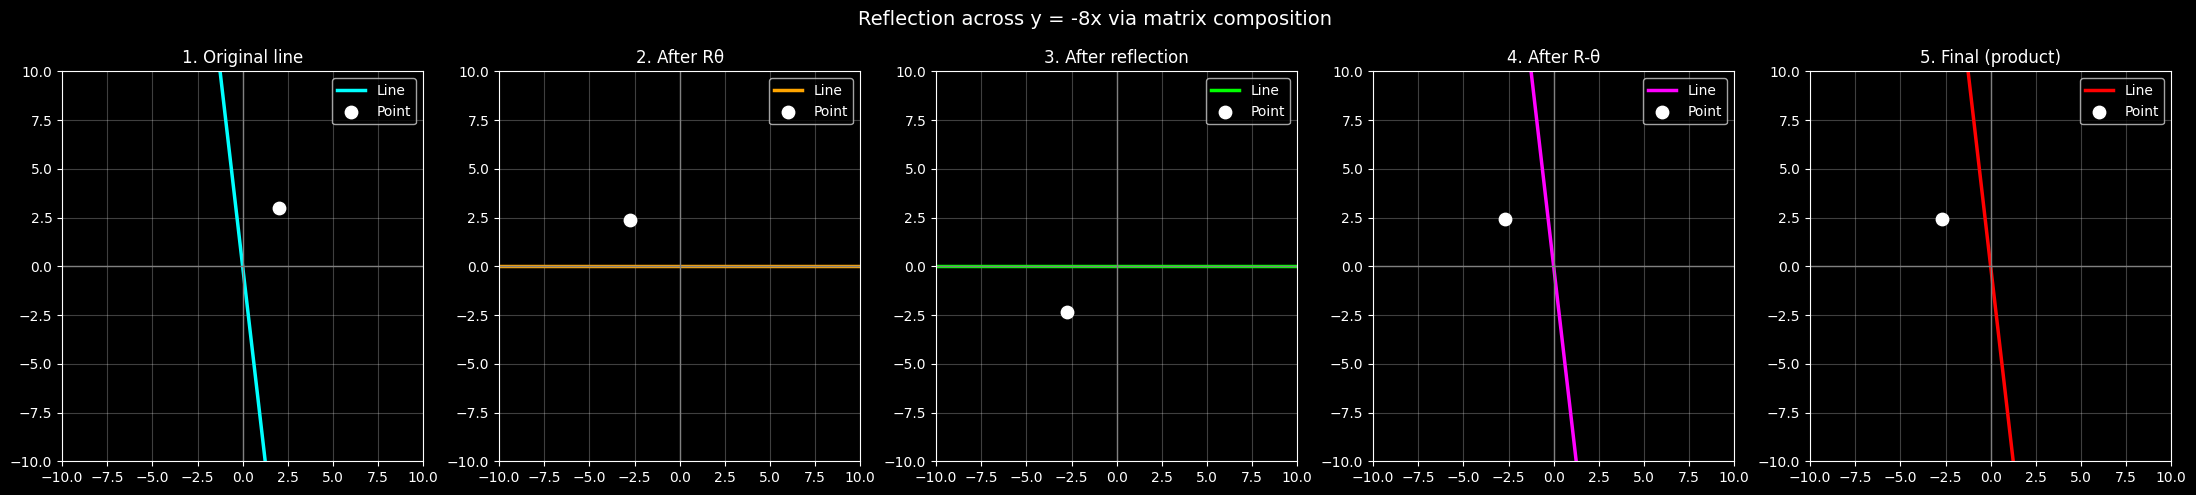

In [27]:
## Plots
# Create the figure with 5 panels
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

titles = [
    "1. Original line",
    "2. After Rθ",
    "3. After reflection",
    "4. After R-θ",
    "5. Final (product)"
]

line_vectors = [v_line, v1, v2, v3, T @ v_line]
point_vectors = [p, p1, p2, p3, p_final]

colors = ["cyan", "orange", "lime", "magenta", "red"]

for ax, title, lv, pv, color in zip(axes, titles, line_vectors, point_vectors, colors):
    draw_line(ax, lv, color, "Line")

    # Show the tracked point as it moves through each step
    ax.scatter(pv[0], pv[1], color="white", s=80, label="Point")

    # Draw axes for reference
    ax.axhline(0, color="gray", linewidth=1)
    ax.axvline(0, color="gray", linewidth=1)

    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.grid(True, alpha=0.25)
    ax.set_title(title)
    ax.legend()

plt.suptitle("Reflection across y = -8x via matrix composition", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/reflection_plot.png", dpi=300, bbox_inches="tight")
plt.show()
